<a href="https://colab.research.google.com/github/LennardBehmann/Intro-ML/blob/main/ML_HW3_Problem1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 3 - Logistical Regression
1) Diabetes dataset.  
2) Cancer dataset.   
All models use an 80/20 training/evaluation split with random_state=42.


Import bibliotheks

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# Problem 1

1.1 Load diabetes dataset and display

In [28]:

url = 'https://raw.githubusercontent.com/LennardBehmann/Intro_ML_HW3/refs/heads/main/diabetes.csv'

df = pd.read_csv(url)

display(df.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


1.2 inspect dataset

In [29]:
print("Dataset shape:", df.shape)

print("\nDataset information:")
df.info()

print("\nSummary statistics:")
display(df.describe())

print("\nClass distribution:")
display(df["Outcome"].value_counts())

Dataset shape: (768, 9)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Summary statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



Class distribution:


,count
Outcome,
0,500
1,268


1.3 Define X and y

In [30]:
X=df[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']].values
y=df['Outcome'].values



#check
print(X[5])
print(y[5])
print("Shape:", X.shape)
print("Shape:", y.shape)

[  5.    116.     74.      0.      0.     25.6     0.201  30.   ]
0
Shape: (768, 8)
Shape: (768,)


1.4 80/20 train-test split

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,    #ensure that data split is the same every time to not mix up training and validation data if started new
    stratify=y
)

#check
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (614, 8)
X_test: (154, 8)
y_train: (614,)
y_test: (154,)


1.5 Standardization

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (614, 8)
X_test_scaled shape: (154, 8)


In [33]:
# Add bias column after standardization
X_train_scaled = np.hstack(
    (np.ones((X_train_scaled.shape[0], 1)), X_train_scaled)
)

X_test_scaled = np.hstack(
    (np.ones((X_test_scaled.shape[0], 1)), X_test_scaled)
)

1.6 Train logistic regression

1.6.1 z-function

In [34]:
theta=np.zeros(X_train_scaled.shape[1])
print(theta)


[0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [35]:
z=X_train_scaled.dot(theta)
print(z)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

1.6.2 define Sigmoid function

In [36]:
def sigmoid(z):
    g = 1 / (1 + np.exp(-z))
    return g

1.6.3 define loss function

In [37]:
def loss(m,p,y):
    loss_value = (-1/m) * (np.dot(y.T, np.log(p)) + np.dot((1-y).T, np.log(1-p)))
    return loss_value

1.6.4 define gradient function

In [38]:
def gradient(X, y, p):
    m = X.shape[0]
    gradient = (1/m) * np.dot(X.T, (p - y))
    return gradient

In [39]:
theta=np.zeros(X_train_scaled.shape[1])
Iterations=1000
learning_rate=0.1
loss_history = []
accuracy_history = []

for i in range(Iterations):
    z = X_train_scaled.dot(theta)
    p = sigmoid(z)

    loss_value = loss(len(y_train), p, y_train)
    loss_history.append(loss_value)

    y_pred = (p >= 0.5).astype(int)
    accuracy = np.mean(y_pred == y_train)
    accuracy_history.append(accuracy)

    gradient_value = gradient(X_train_scaled, y_train, p)
    theta = theta - learning_rate * gradient_value


print(loss_history[0])
print(accuracy_history[0])
print(len(loss_history))
print(len(accuracy_history))
print("Initial loss:", loss_history[0])
print("Final loss:", loss_history[-1])

print("Initial accuracy:", accuracy_history[0])
print("Final accuracy:", accuracy_history[-1])

0.6931471805599452
0.3485342019543974
1000
1000
Initial loss: 0.6931471805599452
Final loss: 0.4662069825435615
Initial accuracy: 0.3485342019543974
Final accuracy: 0.7947882736156352


1.7 Plot training loss

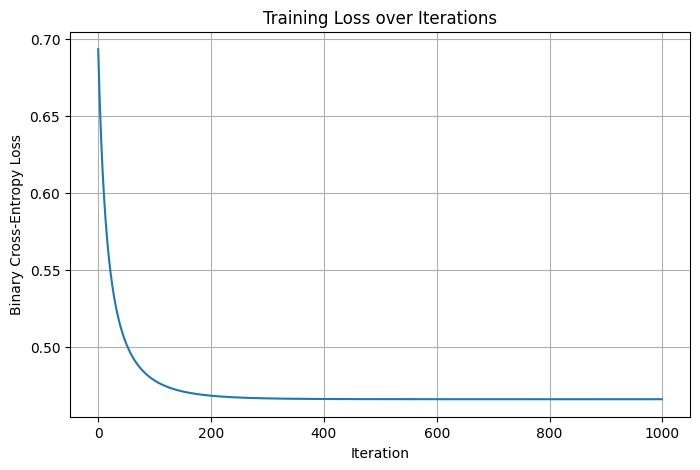

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(range(Iterations), loss_history)

plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Training Loss over Iterations")

plt.grid(True)
plt.show()

1.8 Plot training accuracy

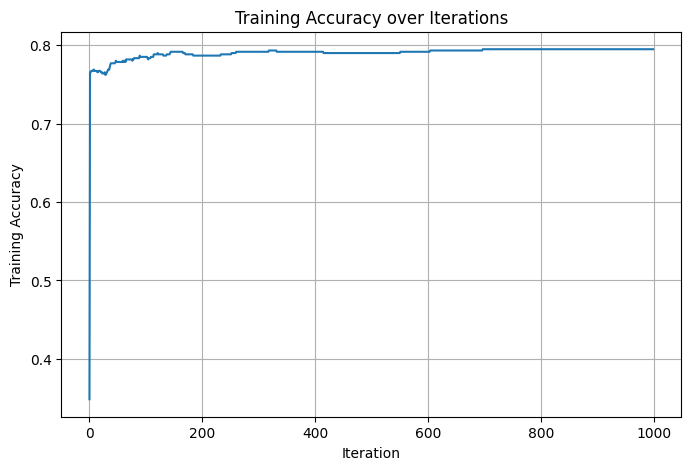

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(range(Iterations), accuracy_history)

plt.xlabel("Iteration")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy over Iterations")

plt.grid(True)
plt.show()

1.8.1 Test for different learning rates

In [42]:
learning_rates = [0.001, 0.01, 0.1]

results = {}

for learning_rate in learning_rates:

    # Reset parameters and histories for each learning rate
    theta = np.zeros(X_train_scaled.shape[1])
    loss_history = []
    accuracy_history = []

    for i in range(Iterations):

        # Linear score
        z = X_train_scaled.dot(theta)

        # Predicted probabilities
        p = sigmoid(z)

        # Loss
        loss_value = loss(len(y_train), p, y_train)
        loss_history.append(loss_value)

        # Training accuracy
        y_pred = (p >= 0.5).astype(int)
        accuracy = np.mean(y_pred == y_train)
        accuracy_history.append(accuracy)

        # Gradient
        gradient_value = gradient(
            X_train_scaled,
            y_train,
            p
        )

        # Update parameters
        theta = theta - learning_rate * gradient_value

    # Store results for this learning rate
    results[learning_rate] = {
        "theta": theta.copy(),
        "loss_history": loss_history.copy(),
        "accuracy_history": accuracy_history.copy()
    }

1.8.2 Plot Loss for different learning rates

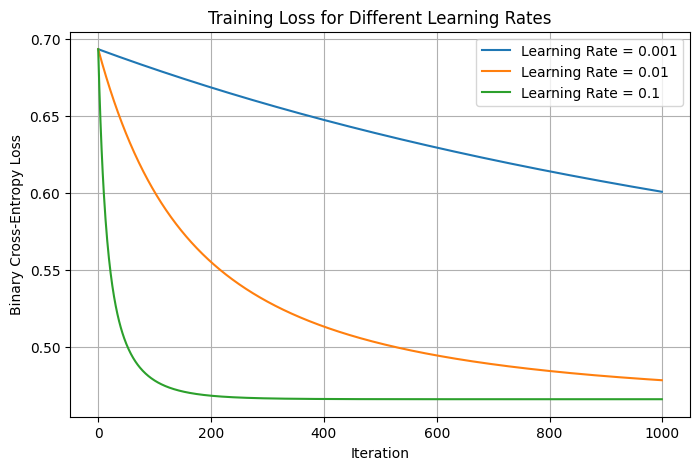

In [43]:
plt.figure(figsize=(8, 5))

for learning_rate in learning_rates:
    plt.plot(
        range(Iterations),
        results[learning_rate]["loss_history"],
        label=f"Learning Rate = {learning_rate}"
    )

plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Training Loss for Different Learning Rates")
plt.legend()
plt.grid(True)

plt.show()

1.8.3 Plot accuracy for differnet learning rates

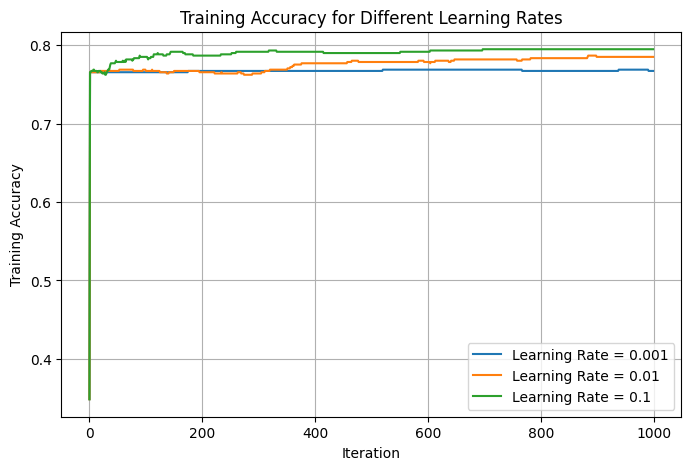

In [44]:
plt.figure(figsize=(8, 5))

for learning_rate in learning_rates:
    plt.plot(
        range(Iterations),
        results[learning_rate]["accuracy_history"],
        label=f"Learning Rate = {learning_rate}"
    )

plt.xlabel("Iteration")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy for Different Learning Rates")
plt.legend()
plt.grid(True)

plt.show()

1.8.4 final values for different learning rates

In [45]:
for learning_rate in learning_rates:
    final_loss = results[learning_rate]["loss_history"][-1]
    final_accuracy = results[learning_rate]["accuracy_history"][-1]

    print(f"Learning Rate: {learning_rate}")
    print(f"Final Loss: {final_loss:.4f}")
    print(f"Final Accuracy: {final_accuracy:.4f}")
    print()

Learning Rate: 0.001
Final Loss: 0.6007
Final Accuracy: 0.7671

Learning Rate: 0.01
Final Loss: 0.4785
Final Accuracy: 0.7850

Learning Rate: 0.1
Final Loss: 0.4662
Final Accuracy: 0.7948



1.8.5 Test 1k iterations with 0.1 learning rate to check if accuracy changes much

In [46]:
theta=np.zeros(X_train_scaled.shape[1])
Iterations=1000
learning_rate=0.1
loss_history = []
accuracy_history = []

for i in range(Iterations):
    z = X_train_scaled.dot(theta)
    p = sigmoid(z)

    loss_value = loss(len(y_train), p, y_train)
    loss_history.append(loss_value)

    y_pred = (p >= 0.5).astype(int)
    accuracy = np.mean(y_pred == y_train)
    accuracy_history.append(accuracy)

    gradient_value = gradient(X_train_scaled, y_train, p)
    theta = theta - learning_rate * gradient_value


print("Initial loss:", loss_history[0])
print("Final loss:", loss_history[-1])

print("Initial accuracy:", accuracy_history[0])
print("Final accuracy:", accuracy_history[-1])

Initial loss: 0.6931471805599452
Final loss: 0.4662069825435615
Initial accuracy: 0.3485342019543974
Final accuracy: 0.7947882736156352


1.9 Evaluate test data

In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate linear scores for test data
z_test = X_test_scaled.dot(theta)

# Convert scores to probabilities
p_test = sigmoid(z_test)

# Convert probabilities to class predictions using threshold 0.5
y_pred_test = (p_test >= 0.5).astype(int)

# Calculate evaluation metrics
test_accuracy = accuracy_score(y_test, y_pred_test)
test_precision = precision_score(y_test, y_pred_test)
test_recall = recall_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test)

# Print results
print("Test Accuracy:", test_accuracy)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)
print("Test F1 Score:", test_f1)

Test Accuracy: 0.7142857142857143
Test Precision: 0.6086956521739131
Test Recall: 0.5185185185185185
Test F1 Score: 0.56


1.10 Confusion matrix

Confusion Matrix:
[[82 18]
 [26 28]]


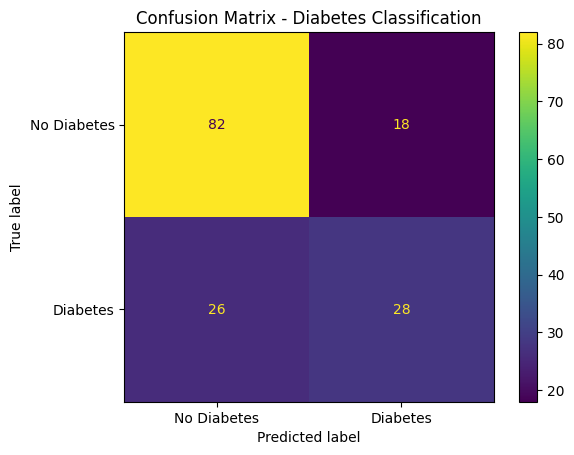

In [48]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)

disp.plot()
plt.title("Confusion Matrix - Diabetes Classification")
plt.show()



1.11 Short interpretation

# Problem 2